# Phase 1 — Hybrid Hierarchical Retrieval on DAPR

This notebook benchmarks document-retriever + passage-retriever pairs before any HiREC cross-encoder or evidence-curation stage. It orchestrates reusable code from `src/hhr_dapr`; it does not hide retrieval or evaluation logic in notebook cells. The checked-in default is a deterministic **synthetic smoke run**, whose measured values validate plumbing only and are not DAPR benchmark results.

## 1. Objective and experiment contract

All selected methods use the same normalized corpus, query set, candidate budgets, and metrics. Parameters may be tuned only on MS MARCO train/dev, are frozen before test/zero-shot evaluation, and NQ-hard is diagnostic-only. Phase 2 may supply a reranker to `HHRPipeline` without changing adapters, metrics, or the experiment runner.

## 2. Environment and reproducibility

In [1]:
from __future__ import annotations

import json
import os
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

START_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in (START_DIR, *START_DIR.parents)
     if (candidate / 'src' / 'hhr_dapr').is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError('Could not locate repository root containing src/hhr_dapr.')
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from hhr_dapr.adapters import ADAPTER_REGISTRY, load_dataset
from hhr_dapr.artifacts import create_run_directory, environment_payload, export_run_artifacts
from hhr_dapr.config import ALL_METHODS, RUN_MODES, config_for_mode
from hhr_dapr.experiments import build_experiment_registry, run_experiment_matrix
from hhr_dapr.metrics import dcg, ndcg_at_k, nq_hard_by_category, recall_at_k
from hhr_dapr.schema import dataset_audit, sample_queries, validate_dataset
from hhr_dapr.synthetic import make_synthetic_dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
pd.set_option('display.max_columns', 100)
print({'project_root': str(PROJECT_ROOT), 'python': sys.version.split()[0], 'seed': SEED})

{'project_root': 'D:\\Work\\kaggle\\chunking benchmark', 'python': '3.10.11', 'seed': 42}


## 3. Centralized run configuration

This is the only run-configuration cell. `smoke` uses four configurations, a small deterministic query set, exact local hashing vectors, and cached embeddings. `baseline` uses all DAPR datasets and four recommended configurations. `full` evaluates all nine. Real runs use the configured asymmetric DRAGON+ checkpoints. Invalid combinations fail before data loading.

In [2]:
# CENTRAL CONFIGURATION — edit this cell, not downstream cells.
CONFIG = {
    'experiment_name': 'phase1_hhr_dapr',
    'run_mode': 'smoke',  # smoke | baseline | full
    'data_root': PROJECT_ROOT / 'data' / 'dapr',
    'cache_dir': PROJECT_ROOT / 'cache' / 'hhr_dapr',
    'output_dir': PROJECT_ROOT / 'outputs',
    'random_seed': 42,
    'dense_query_model': 'facebook/dragon-plus-query-encoder',
    'dense_context_model': 'facebook/dragon-plus-context-encoder',
    'dense_document_strategy': 'title_plus_lead',
    'dense_batch_size': 32,
    'dense_device': 'cpu',
    'sparse_backend': 'native_bm25',
    'combined_strategy': 'hhr_interleave',  # hhr_interleave | rrf
    'rrf_k': 60,
    'score_fusion': 'passage_only',  # passage_only | weighted_sum
    'document_score_weight': 0.0,
    'rebuild_indices': False,
    'save_per_query_results': True,
    'num_workers': 1,
}
RUN_CONFIG = config_for_mode(CONFIG.pop('run_mode'), **CONFIG)
MODE_CONFIG = RUN_MODES[RUN_CONFIG.run_mode]
print(json.dumps(RUN_CONFIG.to_dict(), indent=2))

{
  "experiment_name": "phase1_hhr_dapr",
  "run_mode": "smoke",
  "data_root": "D:\\Work\\kaggle\\chunking benchmark\\data\\dapr",
  "cache_dir": "D:\\Work\\kaggle\\chunking benchmark\\cache\\hhr_dapr",
  "output_dir": "D:\\Work\\kaggle\\chunking benchmark\\outputs",
  "random_seed": 42,
  "datasets": [
    "synthetic"
  ],
  "methods": [
    "sparse+dense",
    "dense+dense",
    "combined+dense",
    "combined+combined"
  ],
  "query_sample_size": 4,
  "document_top_k": 3,
  "passage_top_k": 5,
  "final_top_k": 5,
  "dense_query_model": "facebook/dragon-plus-query-encoder",
  "dense_context_model": "facebook/dragon-plus-context-encoder",
  "dense_document_strategy": "title_plus_lead",
  "dense_document_lead_chars": 4000,
  "dense_batch_size": 32,
  "dense_device": "cpu",
  "dense_backend": "hashing",
  "dense_index": "exact",
  "hashing_features": 512,
  "sparse_backend": "native_bm25",
  "bm25_k1": 1.2,
  "bm25_b": 0.75,
  "combined_strategy": "hhr_interleave",
  "rrf_k": 60,
  "sc

## 4. Dataset registry and reusable adapters

The six manifest adapters normalize MS MARCO, Natural Questions, MIRACL English, Genomics, ConditionalQA, and NQ-hard. Sampling selects query IDs only; it never samples or mixes splits using labels. Missing real artifacts fail with a path and manifest hint.

In [3]:
print('Registered real-data adapters:', sorted(ADAPTER_REGISTRY))
datasets = []
for dataset_name in RUN_CONFIG.datasets:
    raw_dataset = (
        make_synthetic_dataset()
        if dataset_name == 'synthetic'
        else load_dataset(dataset_name, RUN_CONFIG.data_root)
    )
    validate_dataset(raw_dataset)
    evaluation_split = 'test'
    dataset = sample_queries(
        raw_dataset,
        sample_size=RUN_CONFIG.query_sample_size,
        seed=RUN_CONFIG.random_seed,
        split=evaluation_split,
    )
    assert len(dataset.queries) == dataset.queries['query_id'].nunique()
    assert set(dataset.queries['split']) == {evaluation_split}
    assert set(dataset.qrels['query_id']).issubset(set(dataset.queries['query_id']))
    datasets.append(dataset)
print({dataset.name: len(dataset.queries) for dataset in datasets})

Registered real-data adapters: ['conditional_qa', 'genomics', 'miracl_en', 'ms_marco', 'natural_questions', 'nq_hard']
{'synthetic': 4}


## 5. Structural audit without printing large raw documents

In [4]:
dataset_audit_table = pd.DataFrame([dataset_audit(dataset) for dataset in datasets])
assert dataset_audit_table['queries'].sum() == sum(len(dataset.queries) for dataset in datasets)
assert dataset_audit_table['passages'].sum() == sum(len(dataset.passages) for dataset in datasets)
display(dataset_audit_table)

,dataset,documents,passages,queries,qrels,splits,graded_qrels,missing_title_rate,noisy_title_rate,mean_passages_per_document
0,synthetic,4,7,4,4,test,True,0.25,0.0,1.75


## 6. Sparse/dense index preparation

The matrix runner constructs one shared set of indices per dataset and reuses it across methods. Dense context embeddings are fingerprinted and cached. Smoke uses exact search; baseline/full can select FAISS. Document representations use full text for BM25 and the configured title/lead strategy for dense retrieval; truncation, missing titles, and noisy titles are recorded in index metadata.

In [5]:
RUN_CONFIG.cache_dir.mkdir(parents=True, exist_ok=True)
print({
    'cache_dir': str(RUN_CONFIG.cache_dir),
    'rebuild_indices': RUN_CONFIG.rebuild_indices,
    'sparse_backend': RUN_CONFIG.sparse_backend,
    'dense_backend': RUN_CONFIG.dense_backend,
    'dense_index': RUN_CONFIG.dense_index,
    'dense_document_strategy': RUN_CONFIG.dense_document_strategy,
})

{'cache_dir': 'D:\\Work\\kaggle\\chunking benchmark\\cache\\hhr_dapr', 'rebuild_indices': False, 'sparse_backend': 'native_bm25', 'dense_backend': 'hashing', 'dense_index': 'exact', 'dense_document_strategy': 'title_plus_lead'}


## 7. HHR experiment registry

In [6]:
EXPERIMENT_REGISTRY = build_experiment_registry(RUN_CONFIG)
assert set(EXPERIMENT_REGISTRY) == set(ALL_METHODS)
assert len(EXPERIMENT_REGISTRY) == 9
experiment_registry_table = pd.DataFrame([
    {
        'method': experiment.name,
        'document_method': experiment.document_method,
        'passage_method': experiment.passage_method,
        'combined_strategy': experiment.combined_strategy,
        'document_top_k': experiment.document_top_k,
        'passage_top_k': experiment.passage_top_k,
        'selected_in_mode': experiment.name in RUN_CONFIG.methods,
    }
    for experiment in EXPERIMENT_REGISTRY.values()
])
display(experiment_registry_table)

,method,document_method,passage_method,combined_strategy,document_top_k,passage_top_k,selected_in_mode
0,sparse+sparse,sparse,sparse,hhr_interleave,3,5,False
1,sparse+dense,sparse,dense,hhr_interleave,3,5,True
2,sparse+combined,sparse,combined,hhr_interleave,3,5,False
3,dense+sparse,dense,sparse,hhr_interleave,3,5,False
4,dense+dense,dense,dense,hhr_interleave,3,5,True
5,dense+combined,dense,combined,hhr_interleave,3,5,False
6,combined+sparse,combined,sparse,hhr_interleave,3,5,False
7,combined+dense,combined,dense,hhr_interleave,3,5,True
8,combined+combined,combined,combined,hhr_interleave,3,5,True


## 8. Reusable experiment runner

`run_experiment_matrix` calls the same `run_hhr_experiment` contract for every dataset/method. Per-query outputs retain passage/document scores, ranks, sparse/dense source ranks, source method, latency, unique-result count, and candidate survival.

In [7]:
assert all(method in EXPERIMENT_REGISTRY for method in RUN_CONFIG.methods)
print('Scheduled:', [(dataset.name, method) for dataset in datasets for method in RUN_CONFIG.methods])

Scheduled: [('synthetic', 'sparse+dense'), ('synthetic', 'dense+dense'), ('synthetic', 'combined+dense'), ('synthetic', 'combined+combined')]


## 9. Metric validation

These assertions use hand-computed examples. Graded nDCG uses gains `2^relevance - 1`; recall treats every positive judgment as relevant.

In [8]:
manual_relevance = {'high': 2, 'medium': 1, 'none': 0}
manual_actual = 1.0 + 3.0 / np.log2(3)
manual_ideal = 3.0 + 1.0 / np.log2(3)
assert np.isclose(ndcg_at_k(['medium', 'high', 'none'], manual_relevance, 10), manual_actual / manual_ideal)
assert np.isclose(recall_at_k(['none', 'high'], manual_relevance, 2), 0.5)
assert np.isclose(dcg([2, 1], 10), manual_ideal)
print('Hand-computed nDCG@10 and Recall@k checks passed.')

Hand-computed nDCG@10 and Recall@k checks passed.


## 10. Smoke test

In smoke mode this executes four methods over the deterministic local corpus. Other modes execute their selected real-data matrix here.

In [9]:
results = run_experiment_matrix(datasets, RUN_CONFIG)
expected_completed = len(datasets) * len(RUN_CONFIG.methods)
assert len(results) == expected_completed
assert all(result.status == 'completed' for result in results)
assert all(result.run_metadata['reranker'] is None for result in results)
print(f'Completed {len(results)} measured experiment(s).')

Completed 4 measured experiment(s).


## 11. Full experiment matrix

Unscheduled configurations remain explicit `not_run` entries at export; no values are imputed.

In [10]:
aggregate_rows = [
    {'dataset': result.dataset, 'method': result.experiment.name, 'status': result.status, **result.aggregate_metrics}
    for result in results
]
aggregate_method_dataset = pd.DataFrame(aggregate_rows).sort_values(['dataset', 'passage_ndcg@10'], ascending=[True, False])
document_metrics_table = aggregate_method_dataset[[
    'dataset', 'method', 'document_ndcg@10', 'document_recall@5', 'document_recall@20', 'document_recall@100'
]]
passage_metrics_table = aggregate_method_dataset[[
    'dataset', 'method', 'passage_ndcg@10', 'passage_recall@5', 'passage_recall@20',
    'passage_recall@100', 'candidate_survival_rate'
]]
display(aggregate_method_dataset)
display(document_metrics_table)
display(passage_metrics_table)

,dataset,method,status,passage_ndcg@10,passage_recall@5,passage_recall@20,passage_recall@100,document_ndcg@10,document_recall@5,document_recall@20,document_recall@100,candidate_survival_rate,mean_query_latency_ms,p50_query_latency_ms,p95_query_latency_ms,mean_unique_result_count
0,synthetic,sparse+dense,completed,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.419500,0.38535,0.543565,5.00
1,synthetic,dense+dense,completed,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.384125,0.36130,0.443070,5.00
2,synthetic,combined+dense,completed,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.645550,0.67145,0.724785,3.75
3,synthetic,combined+combined,completed,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.015775,0.93085,1.451820,3.00


,dataset,method,document_ndcg@10,document_recall@5,document_recall@20,document_recall@100
0,synthetic,sparse+dense,1.0,1.0,1.0,1.0
1,synthetic,dense+dense,1.0,1.0,1.0,1.0
2,synthetic,combined+dense,1.0,1.0,1.0,1.0
3,synthetic,combined+combined,1.0,1.0,1.0,1.0


,dataset,method,passage_ndcg@10,passage_recall@5,passage_recall@20,passage_recall@100,candidate_survival_rate
0,synthetic,sparse+dense,1.0,1.0,1.0,1.0,1.0
1,synthetic,dense+dense,1.0,1.0,1.0,1.0,1.0
2,synthetic,combined+dense,1.0,1.0,1.0,1.0,1.0
3,synthetic,combined+combined,1.0,1.0,1.0,1.0,1.0


## 12. Dataset/domain comparison

In [11]:
domain_comparison = aggregate_method_dataset.pivot_table(
    index='method', columns='dataset', values=['passage_ndcg@10', 'passage_recall@100']
)
display(domain_comparison)

,passage_ndcg@10,passage_recall@100
dataset,synthetic,synthetic
method,,
combined+combined,1.0,1.0
combined+dense,1.0,1.0
dense+dense,1.0,1.0
sparse+dense,1.0,1.0


## 13. NQ-hard category diagnostics

A multi-label NQ-hard query contributes to every applicable category (CR, MT, MHR, AC); it is never forced into one class. The table is empty with an explicit message when diagnostics are disabled or NQ-hard is not loaded.

In [12]:
nq_rows = []
if RUN_CONFIG.run_nq_hard_analysis:
    nq_dataset = next((dataset for dataset in datasets if dataset.name == 'nq_hard'), None)
    if nq_dataset is None or nq_dataset.query_metadata is None:
        raise RuntimeError('NQ-hard diagnostics require nq_hard query_metadata with question_type.')
    for result in [result for result in results if result.dataset == 'nq_hard']:
        category = nq_hard_by_category(result.per_query_metrics, nq_dataset.query_metadata)
        category.insert(0, 'method', result.experiment.name)
        category.insert(0, 'dataset', 'nq_hard')
        category['status'] = 'completed'
        nq_rows.append(category)
nq_hard_method_category = pd.concat(nq_rows, ignore_index=True) if nq_rows else pd.DataFrame(
    columns=['dataset', 'method', 'category', 'query_count', 'passage_ndcg@10', 'passage_recall@100', 'status']
)
if nq_hard_method_category.empty:
    print('NQ-hard diagnostics: not_run in this mode.')
else:
    display(nq_hard_method_category)

NQ-hard diagnostics: not_run in this mode.


## 14. Effectiveness–latency–storage comparison

,dataset,method,passage_ndcg@10,passage_recall@100,mean_query_latency_ms,p50_query_latency_ms,p95_query_latency_ms,mean_unique_result_count,index_storage_bytes
0,synthetic,sparse+dense,1.0,1.0,0.419500,0.38535,0.543565,5.00,15527
1,synthetic,dense+dense,1.0,1.0,0.384125,0.36130,0.443070,5.00,22528
2,synthetic,combined+dense,1.0,1.0,0.645550,0.67145,0.724785,3.75,23719
3,synthetic,combined+combined,1.0,1.0,1.015775,0.93085,1.451820,3.00,25032


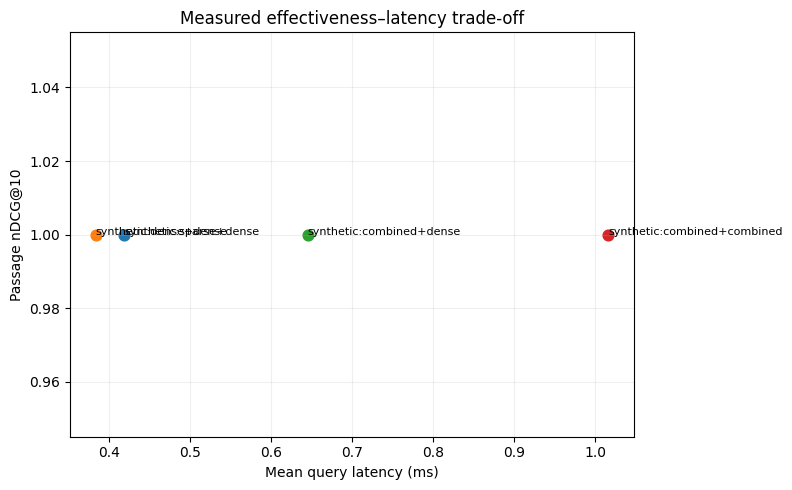

In [13]:
efficiency_table = aggregate_method_dataset[[
    'dataset', 'method', 'passage_ndcg@10', 'passage_recall@100',
    'mean_query_latency_ms', 'p50_query_latency_ms', 'p95_query_latency_ms',
    'mean_unique_result_count'
]].copy()
storage_lookup = {
    (result.dataset, result.experiment.name): result.index_metadata['total_storage_bytes']
    for result in results
}
efficiency_table['index_storage_bytes'] = [
    storage_lookup[(row.dataset, row.method)] for row in efficiency_table.itertuples(index=False)
]
display(efficiency_table)
fig, ax = plt.subplots(figsize=(8, 5))
for row in efficiency_table.itertuples(index=False):
    ax.scatter(row.mean_query_latency_ms, getattr(row, '_2'), s=60)
    ax.annotate(f'{row.dataset}:{row.method}', (row.mean_query_latency_ms, getattr(row, '_2')), fontsize=8)
ax.set_xlabel('Mean query latency (ms)')
ax.set_ylabel('Passage nDCG@10')
ax.set_title('Measured effectiveness–latency trade-off')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 15. Failure analysis

Only query/passage IDs and ranks are shown—never raw corpus text.

In [14]:
failure_rows = []
for result in results:
    relevant = next(dataset.qrels for dataset in datasets if dataset.name == result.dataset)
    relevant = relevant.loc[relevant['relevance'] > 0]
    observed = result.passage_rankings[['query_id', 'passage_id', 'passage_rank', 'document_rank']]
    joined = relevant.merge(observed, on=['query_id', 'passage_id'], how='left')
    for row in joined.loc[joined['passage_rank'].isna()].head(5).itertuples(index=False):
        failure_rows.append({
            'dataset': result.dataset, 'method': result.experiment.name,
            'query_id': row.query_id, 'relevant_passage_id': row.passage_id,
            'relevant_passage_rank': 'not_retrieved',
            'document_rank': 'not_retrieved_or_pruned',
        })
failure_analysis_table = pd.DataFrame(failure_rows, columns=[
    'dataset', 'method', 'query_id', 'relevant_passage_id', 'relevant_passage_rank', 'document_rank'
])
display(failure_analysis_table.head(20))

,dataset,method,query_id,relevant_passage_id,relevant_passage_rank,document_rank


## 16. Artifact export

In [15]:
run_dir, git_commit = create_run_directory(RUN_CONFIG, PROJECT_ROOT)
expected_pairs = [(dataset.name, method) for dataset in datasets for method in ALL_METHODS]
artifact_paths = export_run_artifacts(
    run_dir=run_dir,
    config=RUN_CONFIG,
    results=results,
    dataset_audit=dataset_audit_table,
    expected_pairs=expected_pairs,
    nq_category_results=nq_hard_method_category,
    git_commit=git_commit,
)
required_artifacts = {
    'config', 'environment', 'dataset_audit', 'aggregate_metrics', 'document_metrics',
    'passage_metrics', 'per_query_metrics', 'latency', 'index_sizes',
    'nq_hard_by_category', 'experiment_manifest', 'run_metadata'
}
assert set(artifact_paths) == required_artifacts
assert all(path.is_file() for path in artifact_paths.values())
print('Run directory:', run_dir)
display(pd.DataFrame({'artifact': artifact_paths.keys(), 'path': map(str, artifact_paths.values())}))

Run directory: D:\Work\kaggle\chunking benchmark\outputs\phase1_hhr_dapr\smoke\75beca733ea5


,artifact,path
0,config,D:\Work\kaggle\chunking benchmark\outputs\phas...
1,environment,D:\Work\kaggle\chunking benchmark\outputs\phas...
2,dataset_audit,D:\Work\kaggle\chunking benchmark\outputs\phas...
3,aggregate_metrics,D:\Work\kaggle\chunking benchmark\outputs\phas...
4,document_metrics,D:\Work\kaggle\chunking benchmark\outputs\phas...
5,passage_metrics,D:\Work\kaggle\chunking benchmark\outputs\phas...
6,per_query_metrics,D:\Work\kaggle\chunking benchmark\outputs\phas...
7,latency,D:\Work\kaggle\chunking benchmark\outputs\phas...
8,index_sizes,D:\Work\kaggle\chunking benchmark\outputs\phas...
9,nq_hard_by_category,D:\Work\kaggle\chunking benchmark\outputs\phas...


## 17. Conclusions and Phase 2 handoff

In [16]:
if RUN_CONFIG.use_synthetic_data:
    recommendation = (
        'No DAPR method recommendation: this run used measured synthetic smoke data only. '
        'Run baseline/full on the normalized DAPR artifacts, then select only from measured frozen-test results.'
    )
else:
    method_summary = aggregate_method_dataset.groupby('method', as_index=False).agg(
        mean_ndcg10=('passage_ndcg@10', 'mean'),
        mean_recall100=('passage_recall@100', 'mean'),
        mean_latency_ms=('mean_query_latency_ms', 'mean'),
    ).sort_values(['mean_ndcg10', 'mean_recall100'], ascending=False)
    best = method_summary.iloc[0]
    recommendation = (
        f"Measured Phase 1 recommendation: {best['method']} "
        f"(mean nDCG@10={best['mean_ndcg10']:.4f}, Recall@100={best['mean_recall100']:.4f}). "
        'Retain the complete rankings and add HiREC only through HHRPipeline.reranker in Phase 2.'
    )
print(recommendation)

No DAPR method recommendation: this run used measured synthetic smoke data only. Run baseline/full on the normalized DAPR artifacts, then select only from measured frozen-test results.
